In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/flood_dataset.csv')
df.head()


,Station_Names,Year,Month,Max_Temp,Min_Temp,Rainfall,Relative_Humidity,Wind_Speed,Cloud_Coverage,Bright_Sunshine,Station_Number,X_COR,Y_COR,LATITUDE,LONGITUDE,ALT,Is_Flood
0,Rangamati,1992,5,37.6,23.4,137.0,73.0,1.2,3.6,6.8,41966,725903.30,508021.9,22.67,92.20,63,0
1,Tangail,1997,12,28.8,13.8,28.0,86.0,0.7,2.8,4.9,41909,491982.91,683166.0,24.15,89.55,10,0
2,Bogra,2006,5,37.3,24.4,193.0,77.0,1.3,4.2,6.7,41883,435303.70,751187.5,24.88,89.36,20,0
3,Dinajpur,1995,7,34.5,25.4,472.0,86.0,0.7,6.2,3.7,41863,365790.20,834718.0,25.63,88.66,37,1
4,Ishurdi,2001,8,35.1,26.6,158.0,84.0,1.0,5.6,5.6,41907,402483.20,667640.8,24.12,89.04,14,0


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Step 1: Encode Station_Names (categorical to numeric)
le = LabelEncoder()
df['Station_Names'] = le.fit_transform(df['Station_Names'])

# Step 2: Drop irrelevant or high-correlation columns
df_cleaned = df.drop(columns=['X_COR', 'Y_COR', 'LATITUDE', 'LONGITUDE', 'Station_Number'])

# Step 3: Separate features and label
X = df_cleaned.drop(columns=['Is_Flood'])
y = df_cleaned['Is_Flood']

# Step 4: Normalize features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [4]:
from xgboost import XGBClassifier

# Train the model
xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Predict using the trained model
y_pred = xgb_model.predict(X_test)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [16:38:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print("📊 XGBoost Evaluation Results:")
print(f"Accuracy :  {accuracy:.2f}")
print(f"Precision:  {precision:.2f}")
print(f"Recall   :  {recall:.2f}")
print(f"F1 Score :  {f1:.2f}")


📊 XGBoost Evaluation Results:
Accuracy :  0.92
Precision:  0.92
Recall   :  0.73
F1 Score :  0.81


<Figure size 600x400 with 0 Axes>

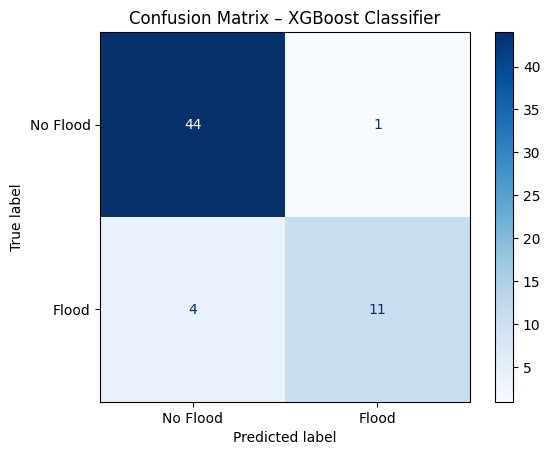

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Flood", "Flood"])

# Plot
plt.figure(figsize=(6, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix – XGBoost Classifier")
plt.grid(False)
plt.show()


In [7]:
from sklearn.ensemble import RandomForestClassifier

# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)


In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluation
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

# Display results
print("📊 Random Forest Evaluation Results:")
print(f"Accuracy :  {rf_accuracy:.2f}")
print(f"Precision:  {rf_precision:.2f}")
print(f"Recall   :  {rf_recall:.2f}")
print(f"F1 Score :  {rf_f1:.2f}")


📊 Random Forest Evaluation Results:
Accuracy :  0.95
Precision:  1.00
Recall   :  0.80
F1 Score :  0.89


<Figure size 600x400 with 0 Axes>

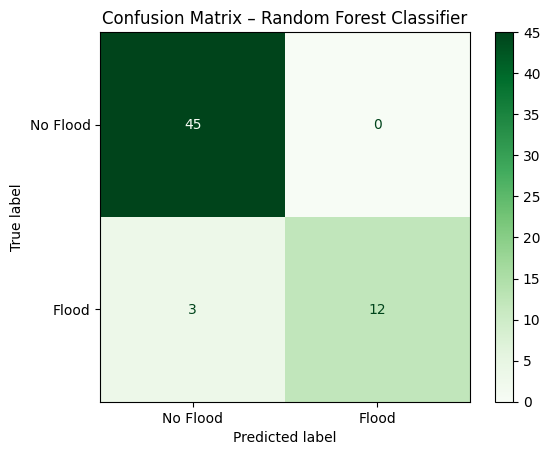

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No Flood", "Flood"])

# Plot
plt.figure(figsize=(6, 4))
disp_rf.plot(cmap="Greens", values_format="d")
plt.title("Confusion Matrix – Random Forest Classifier")
plt.grid(False)
plt.show()


In [10]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Select relevant time series features
lstm_df = df[['Year', 'Month', 'Rainfall', 'Max_Temp', 'Min_Temp', 'Relative_Humidity']]

# Sort by time
lstm_df = lstm_df.sort_values(by=['Year', 'Month'])

# Normalize
scaler = MinMaxScaler()
lstm_scaled = scaler.fit_transform(lstm_df[['Rainfall', 'Max_Temp', 'Min_Temp', 'Relative_Humidity']])

# Create sequences (12 months history → next month's rainfall)
def create_sequences(data, window_size=12):
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size][0])  # Rainfall is first column
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(lstm_scaled, window_size=12)

# Train-test split (80% train, 20% test)
split = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]

# Reshape for LSTM [samples, time steps, features]
print("Input shape for LSTM:", X_train_lstm.shape)


Input shape for LSTM: (230, 12, 4)


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Build the LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(12, 4)))
model.add(Dense(1))  # Output layer (rainfall prediction)

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train_lstm, y_train_lstm, epochs=100, batch_size=16, validation_data=(X_test_lstm, y_test_lstm), verbose=1)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0257 - mae: 0.1177 - val_loss: 0.0227 - val_mae: 0.1179
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0259 - mae: 0.1202 - val_loss: 0.0214 - val_mae: 0.1185
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0204 - mae: 0.1041 - val_loss: 0.0202 - val_mae: 0.1150
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0218 - mae: 0.1106 - val_loss: 0.0189 - val_mae: 0.1063
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0231 - mae: 0.1096 - val_loss: 0.0178 - val_mae: 0.1006
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0222 - mae: 0.1040 - val_loss: 0.0167 - val_mae: 0.1015
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0211 - mae: 0.0956 - val_loss: 0.0162 - val_mae: 0.1001
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0218 - mae: 0.1030 - val_loss: 0.0155 - val_mae: 0.0982
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0189 -

In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Predict
y_pred_lstm = model.predict(X_test_lstm)

# Inverse transform to original rainfall scale
y_pred_rescaled = scaler.inverse_transform(np.concatenate([y_pred_lstm, np.zeros((len(y_pred_lstm), 3))], axis=1))[:, 0]
y_test_rescaled = scaler.inverse_transform(np.concatenate([y_test_lstm.reshape(-1, 1), np.zeros((len(y_test_lstm), 3))], axis=1))[:, 0]

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)

print("📊 LSTM Rainfall Prediction Evaluation:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
📊 LSTM Rainfall Prediction Evaluation:
RMSE: 209.04
MAE : 136.15


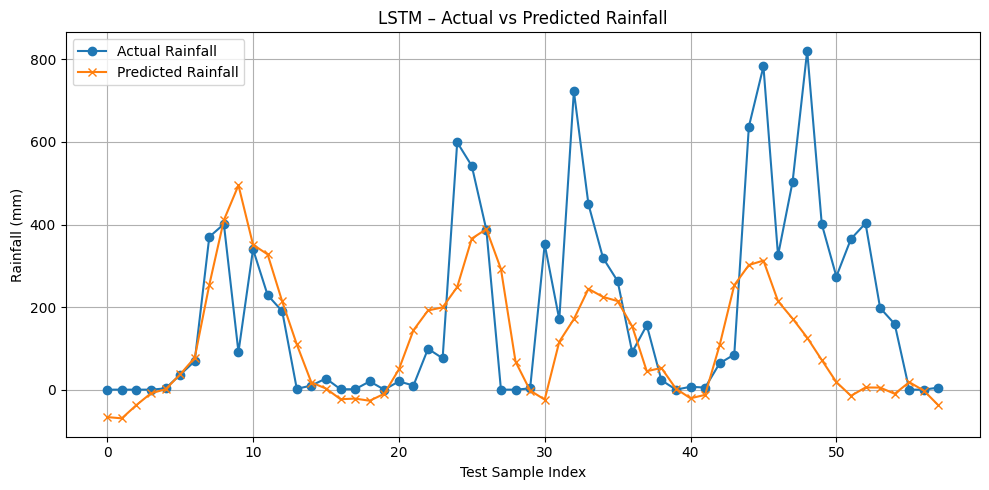

In [13]:
import matplotlib.pyplot as plt

# Plot actual vs predicted rainfall
plt.figure(figsize=(10, 5))
plt.plot(y_test_rescaled, label='Actual Rainfall', marker='o')
plt.plot(y_pred_rescaled, label='Predicted Rainfall', marker='x')
plt.title('LSTM – Actual vs Predicted Rainfall')
plt.xlabel('Test Sample Index')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
from sklearn.svm import SVC

# Train the SVM model
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')  # RBF kernel for non-linear classification
svm_model.fit(X_train, y_train)

# Predict
svm_pred = svm_model.predict(X_test)


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluation
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred)
svm_recall = recall_score(y_test, svm_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("📊 SVM Evaluation Results:")
print(f"Accuracy :  {svm_accuracy:.2f}")
print(f"Precision:  {svm_precision:.2f}")
print(f"Recall   :  {svm_recall:.2f}")
print(f"F1 Score :  {svm_f1:.2f}")


📊 SVM Evaluation Results:
Accuracy :  0.93
Precision:  1.00
Recall   :  0.73
F1 Score :  0.85


<Figure size 600x400 with 0 Axes>

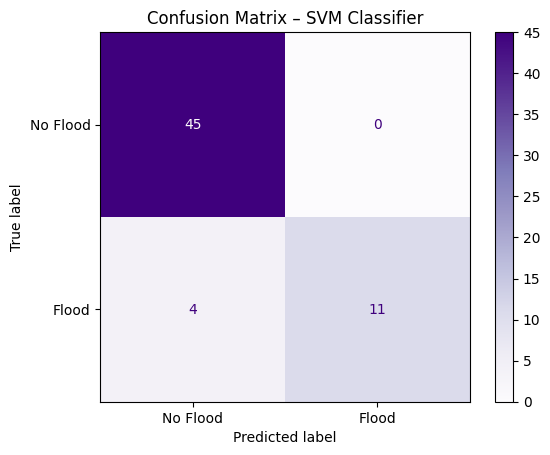

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_pred)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["No Flood", "Flood"])

# Plot
plt.figure(figsize=(6, 4))
disp_svm.plot(cmap="Purples", values_format="d")
plt.title("Confusion Matrix – SVM Classifier")
plt.grid(False)
plt.show()


In [17]:
from sklearn.neighbors import KNeighborsClassifier

# Train the KNN model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predict
knn_pred = knn_model.predict(X_test)


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Evaluation
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred)
knn_recall = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("📊 KNN Evaluation Results:")
print(f"Accuracy :  {knn_accuracy:.2f}")
print(f"Precision:  {knn_precision:.2f}")
print(f"Recall   :  {knn_recall:.2f}")
print(f"F1 Score :  {knn_f1:.2f}")


📊 KNN Evaluation Results:
Accuracy :  0.88
Precision:  1.00
Recall   :  0.53
F1 Score :  0.70


<Figure size 600x400 with 0 Axes>

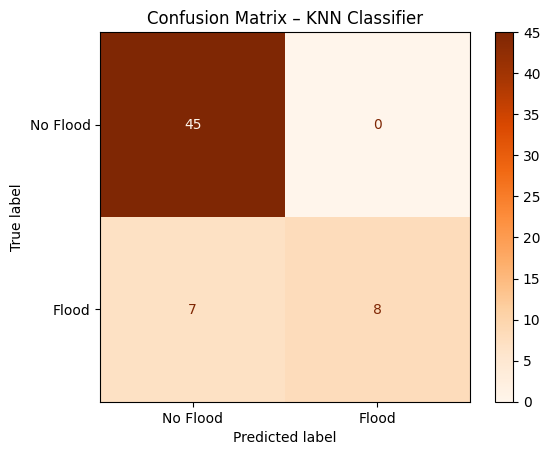

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix
cm_knn = confusion_matrix(y_test, knn_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["No Flood", "Flood"])

# Plot
plt.figure(figsize=(6, 4))
disp_knn.plot(cmap="Oranges", values_format="d")
plt.title("Confusion Matrix – KNN Classifier")
plt.grid(False)
plt.show()
